In [1]:
from dataclasses import dataclass
from enum import StrEnum
from datetime import datetime, timedelta, date
import polars as pl
from collections import defaultdict, Counter
from typing import Tuple
from common.constants.column_types import (
    CPZP_SCHEMA,
    OZP_SCHEMA,
    POHLAVI_CPZP,
    TYP_UDALOSTI,
)
from common.constants.column_names import SHARED_COLUMNS, OZP_COLUMNS, CPZP_COLUMNS
import pickle
from common.constants.objects import (
    Person,
    Gender,
    AgeCohort,
    Prescription,
    PrescriptionType,
)
import matplotlib.pyplot as plt
import numpy as np
import os
from common.utils import (
    draw_chart,
    filter_by_date_range,
)
from bisect import bisect_left, bisect_right
import random

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(60)

pl.Config.set_tbl_rows(-1)


ZACATEK_POJISTENI = date(2015, 1, 1)
KONEC_POJISTENI = date(2023, 12, 31)


class AgeCohort(StrEnum):
    _12_15 = "12-15"
    _16_29 = "16-29"
    _30_49 = "30-49"
    _50_59 = "50-59"
    IRRELEVANT = "irrelevant"


def calculate_age_cohort(person: Person) -> AgeCohort:
    YEAR_FOR_AGE_CALCULATION = 2021

    age = YEAR_FOR_AGE_CALCULATION - person.born_at.year
    if age >= 12 and age <= 15:
        return AgeCohort._12_15
    elif age >= 16 and age <= 29:
        return AgeCohort._16_29
    elif age >= 30 and age <= 49:
        return AgeCohort._30_49
    elif age >= 50 and age <= 59:
        return AgeCohort._50_59
    else:
        return AgeCohort.IRRELEVANT


def is_injection(pr: Prescription) -> bool:
    return pr.lekova_forma_zkr and (pr.lekova_forma_zkr.startswith("INJ"))


def create_prednison_enum(step: int = 25, max_value: int = 5000):
    values = {"ZERO": "zero", f"MORE_THAN_{max_value}": f"more_than_{max_value}"}

    for start in range(0, max_value, step):
        end = start + step
        name = f"BETWEEN_{start}_AND_{end}"
        values[name] = name.lower()

    return StrEnum("PREDNISON_EQUIV_CATEGORY", values)


PREDNISON_EQUIV_CATEGORY = create_prednison_enum()


def from_prednison_equiv(prednison_equiv: float) -> PREDNISON_EQUIV_CATEGORY:
    if prednison_equiv == 0:
        return PREDNISON_EQUIV_CATEGORY.ZERO

    step = 25
    max_value = 5000

    if prednison_equiv >= max_value:
        return PREDNISON_EQUIV_CATEGORY[f"MORE_THAN_{max_value}"]

    start = int((prednison_equiv // step) * step)
    end = start + step
    name = f"BETWEEN_{start}_AND_{end}"
    return PREDNISON_EQUIV_CATEGORY[name]


def find_matching_person(
    vax_person: Person,
    pe_range: PREDNISON_EQUIV_CATEGORY,
    vax_date: datetime,
    novax_map: dict[PREDNISON_EQUIV_CATEGORY, dict[AgeCohort, dict[Gender, set[int]]]],
) -> str:
    ac = calculate_age_cohort(vax_person)
    gender = vax_person.gender
    novax_matched_ids = novax_map[vax_date][pe_range][ac][gender]
    max_int = len(novax_matched_ids)
    random_index = random.randint(0, max_int - 1)
    return novax_matched_ids[random_index]


def sum_after_date_pe_for_person(person: Person, ddate: datetime) -> float:
    return sum(
        pr.prednison_equiv
        for pr in person.prescriptions
        if (not is_injection(pr))
        and (pr.date > ddate and pr.date < ddate + timedelta(days=365))
    )


def sum_before_date_pe_for_person(person: Person, ddate: datetime) -> float:
    return sum(
        pr.prednison_equiv
        for pr in person.prescriptions
        if (not is_injection(pr))
        and (pr.date > ddate - timedelta(days=365) and pr.date < ddate)
    )


STRATEGICKE_PROFESE_ZACATEK = {
    AgeCohort._12_15: date(2021, 1, 1),
    AgeCohort._16_29: date(2021, 1, 1),
    AgeCohort._30_49: date(2021, 1, 1),
    AgeCohort._50_59: date(2021, 1, 1),
}


ZDRAVOTNI_INDIKACE = {
    AgeCohort._12_15: date(2021, 3, 31),
    AgeCohort._16_29: date(2021, 3, 31),
    AgeCohort._30_49: date(2021, 3, 31),
    AgeCohort._50_59: date(2021, 3, 31),
}


OTEVRENI_NEJSTARSI_CASTI_HLAVNI_PERIODA = {
    AgeCohort._12_15: date(2021, 7, 1),
    AgeCohort._16_29: date(2021, 6, 4),
    AgeCohort._30_49: date(2021, 5, 10),
    AgeCohort._50_59: date(2021, 4, 24),
}

In [2]:
POJISTOVNA = "cpzp"
if POJISTOVNA == "both_companies":
    with open("./DATACON_data/cpzp_persons.pkl", "rb") as f:
        cpzp_persons: list[Person] = pickle.load(f)
    with open("./DATACON_data/ozp_persons.pkl", "rb") as f:
        ozp_persons: list[Person] = pickle.load(f)
    persons = cpzp_persons + ozp_persons
else:
    with open(f"./DATACON_data/{POJISTOVNA}_persons.pkl", "rb") as f:
        persons: list[Person] = pickle.load(f)

for p in persons:
    if p.ukonceni_pojisteni is None:
        p.ukonceni_pojisteni = date(2050, 12, 31)

In [3]:
novax_persons_to_analyse = [
    p
    for p in persons
    if not p.vaccines
    and p.died_at is None
    and (
        p.zahajeni_pojisteni < ZACATEK_POJISTENI
        and p.ukonceni_pojisteni > KONEC_POJISTENI
    )
]

person_map = {p.id: p for p in persons}
vax_people = [
    p
    for p in persons
    if p.vaccines
    and p.died_at is None  # klidně do roku 2023
    and (
        p.zahajeni_pojisteni < ZACATEK_POJISTENI
        and p.ukonceni_pojisteni > KONEC_POJISTENI
    )
]

In [4]:
vax_people = [p for p in vax_people if calculate_age_cohort(p) == AgeCohort._16_29]

In [5]:
vax_people_main_timeframe = []
vax_people_health_indicator_timeframe = []
vax_people_strategic_timeframe = []
for p in vax_people:
    first_vax_date = p.vaccines[0].date
    age_cohort = calculate_age_cohort(p)
    if age_cohort == AgeCohort.IRRELEVANT:
        continue
    if first_vax_date >= OTEVRENI_NEJSTARSI_CASTI_HLAVNI_PERIODA[age_cohort]:
        vax_people_main_timeframe.append(p)
    elif first_vax_date >= ZDRAVOTNI_INDIKACE[age_cohort]:
        vax_people_health_indicator_timeframe.append(p)
    elif first_vax_date >= STRATEGICKE_PROFESE_ZACATEK[age_cohort]:
        vax_people_strategic_timeframe.append(p)


In [6]:
def get_different_pe_cohorts(vax_cohort_people: list[Person]) -> list[list[Person]]:
    zero_pe_vax_people = [
        p
        for p in vax_cohort_people
        if sum_before_date_pe_for_person(p, p.vaccines[0].date) == 0
    ]
    one_to_five_hundred_pe_vax_people = [
        p
        for p in vax_cohort_people
        if sum_before_date_pe_for_person(p, p.vaccines[0].date) >= 1
        and sum_before_date_pe_for_person(p, p.vaccines[0].date) < 500
    ]
    five_hundred_to_five_thousand_pe_vax_people = [
        p
        for p in vax_cohort_people
        if sum_before_date_pe_for_person(p, p.vaccines[0].date) >= 500
        and sum_before_date_pe_for_person(p, p.vaccines[0].date) < 5000
    ]
    return [
        zero_pe_vax_people,
        one_to_five_hundred_pe_vax_people,
        five_hundred_to_five_thousand_pe_vax_people,
    ]


(
    zero_pe_vax_people,
    one_to_five_hundred_pe_vax_people,
    five_hundred_to_five_thousand_pe_vax_people,
) = get_different_pe_cohorts(vax_people)

START_DATE = datetime(2021, 1, 1)
anchor_dates = [
    (START_DATE + timedelta(days=i)).date()
    for i in range((datetime(2022, 2, 28) - START_DATE).days + 1)
]

In [6]:
def compute_prednison_windows(
    people: list[Person], vax_anchor_dates: list[datetime]
) -> dict[datetime, dict[str | int, float]]:
    # Prepare output structure
    result: dict[
        datetime,
        dict[PREDNISON_EQUIV_CATEGORY, dict[AgeCohort, dict[Gender, set[int]]]],
    ] = {ad: {} for ad in vax_anchor_dates}

    completed_persons = 0
    len_of_persons_to_analyse = len(people)
    for person in people:
        completed_persons += 1
        print(
            f"Processing person {completed_persons}/{len_of_persons_to_analyse}",
            end="\r",
        )

        # person_prescriptions = sorted(person.prescriptions, key=lambda pr: pr.date)
        person_prescriptions = [
            pr
            for pr in sorted(person.prescriptions, key=lambda pr: pr.date)
            if not (is_injection(pr))
        ]
        if not person_prescriptions:
            # no prescriptions → all anchor dates = 0
            for anchor in vax_anchor_dates:
                # result[ad][person.id] = 0.0
                pe_range = from_prednison_equiv(0)
                if pe_range not in result[anchor]:
                    result[anchor][pe_range] = {}

                ac = calculate_age_cohort(person)
                if ac not in result[anchor][pe_range]:
                    result[anchor][pe_range][ac] = {}

                if person.gender not in result[anchor][pe_range][ac]:
                    result[anchor][pe_range][ac][person.gender] = set()

                result[anchor][pe_range][ac][person.gender].add(person.id)
            continue

        # For accumulation:
        # Each anchor date holds its sum of prednison for this person
        per_person_map: dict[datetime, float] = {ad: 0.0 for ad in vax_anchor_dates}

        # 3) For each prescription, add its value to all anchor dates
        #    within pr.date → pr.date + 365 days
        for pr in person_prescriptions:
            start = pr.date
            end = pr.date + timedelta(days=365)

            # indices of anchor dates inside [start, end]
            i = bisect_left(vax_anchor_dates, start)
            j = bisect_right(vax_anchor_dates, end)

            # Add prednison_equiv to each matching anchor date
            for idx in range(i, j):
                anchor = vax_anchor_dates[idx]
                per_person_map[anchor] += pr.prednison_equiv

        # Store per-person results
        for anchor, value in per_person_map.items():
            # result[anchor][person.id] = value
            pe_range = from_prednison_equiv(value)
            if pe_range not in result[anchor]:
                result[anchor][pe_range] = {}

            ac = calculate_age_cohort(person)
            if ac not in result[anchor][pe_range]:
                result[anchor][pe_range][ac] = {}

            if person.gender not in result[anchor][pe_range][ac]:
                result[anchor][pe_range][ac][person.gender] = set()

            result[anchor][pe_range][ac][person.gender].add(person.id)

    for anchor, ranges in result.items():
        for pe_range, acs in ranges.items():
            for ac, genders in acs.items():
                for gender, idset in genders.items():
                    genders[gender] = list(idset)

    return result


pe_map = compute_prednison_windows(novax_persons_to_analyse, anchor_dates)


In [7]:
# import pickle

# with open("both_companies_pe_map.pkl", "wb") as f:
#     pickle.dump(pe_map, f)


import pickle

with open("cpzp_pe_map.pkl", "rb") as f:
    pe_map = pickle.load(f)


In [7]:
def aggregate_date(start_date: date, window_days: int) -> datetime:
    start_date = datetime(start_date.year, start_date.month, start_date.day)
    if window_days <= 1:
        return start_date

    epoch = START_DATE
    days_since_epoch = (start_date - epoch).days
    window_start_days = (days_since_epoch // window_days) * window_days
    return epoch + timedelta(days=window_start_days)


def compute_vax_vs_novax_sums(people, aggregation_days: int = 1):
    vax_before_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    vax_after_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    novax_before_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    novax_after_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )

    print("iterating through people ", len(people))

    for person in people:
        first_vax = person.vaccines[0]

        vax_person_before_pe = sum_before_date_pe_for_person(person, first_vax.date)
        if vax_person_before_pe > 5000:
            continue

        pe_range = from_prednison_equiv(vax_person_before_pe)
        try:
            matched_id = find_matching_person(person, pe_range, first_vax.date, pe_map)
        except Exception:
            continue

        matched_person = person_map[matched_id]

        vax_person_after_pe = sum_after_date_pe_for_person(person, first_vax.date)
        novax_person_before_pe = sum_before_date_pe_for_person(
            matched_person, first_vax.date
        )
        novax_person_after_pe = sum_after_date_pe_for_person(
            matched_person, first_vax.date
        )

        ac = calculate_age_cohort(person)

        aggregated_date = aggregate_date(first_vax.date, aggregation_days)

        vax_before_pe_map[ac][aggregated_date] += vax_person_before_pe
        vax_after_pe_map[ac][aggregated_date] += vax_person_after_pe
        novax_before_pe_map[ac][aggregated_date] += novax_person_before_pe
        novax_after_pe_map[ac][aggregated_date] += novax_person_after_pe

    return (
        vax_before_pe_map,
        vax_after_pe_map,
        novax_before_pe_map,
        novax_after_pe_map,
    )


In [8]:
EffectMap = dict[AgeCohort, dict[datetime, float]]


def run_matching_analysis(
    people,
    aggregation_days: int,
    group_name: str,
    num_runs: int = 100,
) -> tuple[
    EffectMap,
    dict[AgeCohort, dict[datetime, tuple[float, float]]],
    dict[AgeCohort, dict[datetime, tuple[float, float]]],
    dict[AgeCohort, dict[datetime, list[float]]],
    EffectMap,
    EffectMap,
]:
    effects: dict[AgeCohort, dict[datetime, list[float]]] = defaultdict(
        lambda: defaultdict(list)
    )
    vax_ratio_effects: dict[AgeCohort, dict[datetime, list[float]]] = defaultdict(
        lambda: defaultdict(list)
    )
    novax_ratio_effects: dict[AgeCohort, dict[datetime, list[float]]] = defaultdict(
        lambda: defaultdict(list)
    )

    for i in range(num_runs):
        vax_before, vax_after, novax_before, novax_after = compute_vax_vs_novax_sums(
            people, aggregation_days
        )

        result_map = compute_effect_values(
            vax_before, vax_after, novax_before, novax_after, group_name
        )

        # Also accumulate vax_after/vax_before and novax_after/novax_before for each run
        all_cohorts = (
            set(vax_before.keys())
            | set(vax_after.keys())
            | set(novax_before.keys())
            | set(novax_after.keys())
        )
        for cohort in all_cohorts:
            all_dates = (
                set(vax_before[cohort].keys())
                | set(vax_after[cohort].keys())
                | set(novax_before[cohort].keys())
                | set(novax_after[cohort].keys())
            )
            for dt in all_dates:
                vax_before_val = vax_before[cohort].get(dt, 0.0)
                vax_after_val = vax_after[cohort].get(dt, 0.0)
                novax_before_val = novax_before[cohort].get(dt, 0.0)
                novax_after_val = novax_after[cohort].get(dt, 0.0)

                vax_ratio = (
                    vax_after_val / vax_before_val
                    if vax_before_val != 0
                    else float("nan")
                )
                novax_ratio = (
                    novax_after_val / novax_before_val
                    if novax_before_val != 0
                    else float("nan")
                )

                vax_ratio_effects[cohort][dt].append(vax_ratio)
                novax_ratio_effects[cohort][dt].append(novax_ratio)

        for cohort, date_map in result_map.items():
            for dt, value in date_map.items():
                effects[cohort][dt].append(value)

        print(f"Processed {i} runs")

    median_map, iqr_map, ci_map = compute_statistics(effects)
    vax_ratio_median_map, _, _ = compute_statistics(vax_ratio_effects)
    novax_ratio_median_map, _, _ = compute_statistics(novax_ratio_effects)

    return (
        median_map,
        iqr_map,
        ci_map,
        effects,
        vax_ratio_median_map,
        novax_ratio_median_map,
    )


def compute_effect_values(
    vax_before_pe_map,
    vax_after_pe_map,
    novax_before_pe_map,
    novax_after_pe_map,
    group_name,
) -> EffectMap:
    result_map: EffectMap = defaultdict(dict)

    cohorts = (
        set(vax_before_pe_map.keys())
        | set(vax_after_pe_map.keys())
        | set(novax_before_pe_map.keys())
        | set(novax_after_pe_map.keys())
    )

    for cohort in cohorts:
        all_dates = (
            set(vax_before_pe_map[cohort].keys())
            | set(vax_after_pe_map[cohort].keys())
            | set(novax_before_pe_map[cohort].keys())
            | set(novax_after_pe_map[cohort].keys())
        )

        for dt in all_dates:
            vax_before = vax_before_pe_map[cohort].get(dt, 0.0)
            vax_after = vax_after_pe_map[cohort].get(dt, 0.0)
            novax_before = novax_before_pe_map[cohort].get(dt, 0.0)
            novax_after = novax_after_pe_map[cohort].get(dt, 0.0)

            if group_name == "0_PE":
                if novax_after != 0:
                    result_map[cohort][dt] = vax_after / novax_after
            else:
                if vax_before != 0 and novax_before != 0:
                    result_map[cohort][dt] = (vax_after / vax_before) - (
                        novax_after / novax_before
                    )

    return result_map


def compute_statistics(
    effects: dict[AgeCohort, dict[datetime, list[float]]],
) -> tuple[EffectMap, EffectMap, EffectMap]:
    median_map: EffectMap = defaultdict(dict)
    iqr_map: dict[AgeCohort, dict[datetime, tuple[float, float]]] = defaultdict(dict)
    ci_map: EffectMap = defaultdict(dict)

    for cohort, date_map in effects.items():
        for dt, values in date_map.items():
            arr = np.asarray(values)

            median = np.median(arr)
            q1, q3 = np.percentile(arr, [25, 75])
            ci_low, ci_high = np.percentile(arr, [2.5, 97.5])

            median_map[cohort][dt] = median
            iqr_map[cohort][dt] = (q1, q3)
            ci_map[cohort][dt] = (ci_low, ci_high)

    return median_map, iqr_map, ci_map


def get_vax_dates_distribution(
    group, aggregation_days: int
) -> dict[AgeCohort, dict[datetime, float]]:
    vax_dates_distribution: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )

    for vax_person in group:
        ac = calculate_age_cohort(vax_person)
        vax_date = vax_person.vaccines[0].date
        aggregated_date = aggregate_date(vax_date, aggregation_days)

        vax_dates_distribution[ac][aggregated_date] += 1

    return vax_dates_distribution


In [9]:
def plot_vax_dates_distribution(
    vax_dates_distribution, pe_cohort: str, aggregation_days: int
):
    sorted_dates = sorted(vax_dates_distribution.keys())
    vax_counts = [vax_dates_distribution.get(d, 0) for d in sorted_dates]
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_dates, vax_counts)
    plt.xlabel("Date of First Vaccination")
    plt.ylabel("Number of People")
    plt.title(f"First Vaccine Dates Over Time - {pe_cohort} - {aggregation_days} days")
    plt.xlim(date(2021, 1, 1), date(2022, 2, 28))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        f"out/{POJISTOVNA}/quick_filip_control/vax_dates_distribution_{pe_cohort}_{aggregation_days}days.png"
    )
    plt.show()
    plt.close()


def plot_treatment_effect(effects, pe_cohort, aggregation_days):
    sorted_dates = sorted(effects.keys())
    effects_values = [effects.get(d, 0) for d in sorted_dates]
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_dates, effects_values)
    plt.xlabel("Date of First Vaccination")
    plt.ylabel("Treatment Effect (after/before)")
    plt.title(f"Treatment Effect Over Time - {pe_cohort} - {aggregation_days} days")
    plt.xlim(date(2021, 1, 1), date(2022, 2, 28))
    plt.savefig(
        f"out/{POJISTOVNA}/quick_filip_control/treatment_effect_{pe_cohort}_{aggregation_days}days.png"
    )
    plt.show()
    plt.close()


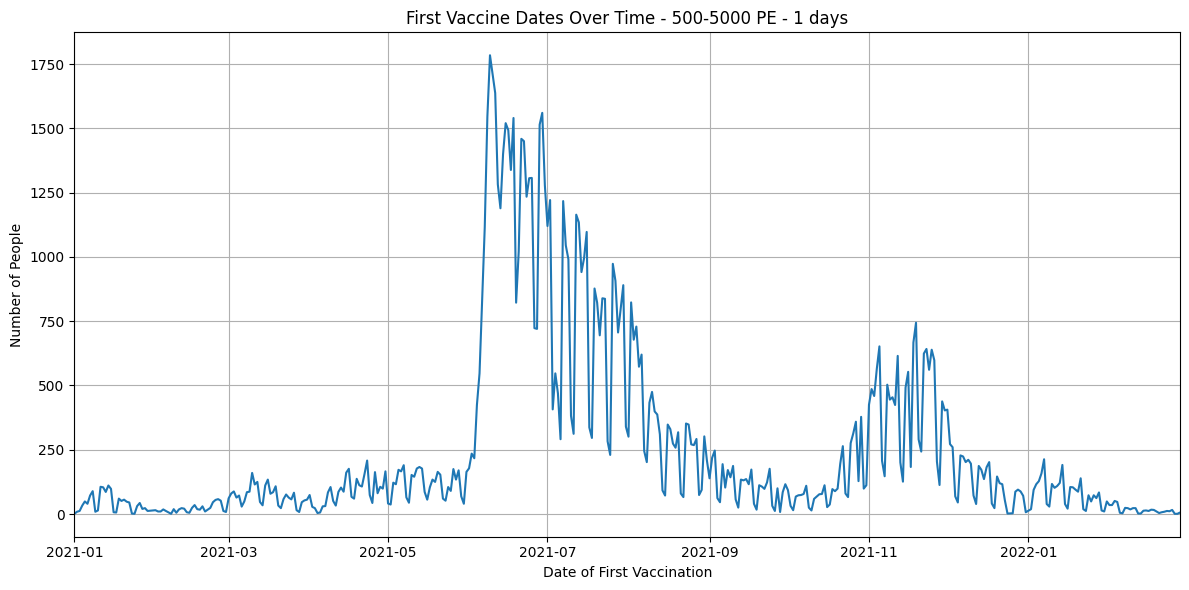

In [13]:
aggregation_days = 1
vax_dates_distribution = get_vax_dates_distribution(vax_people, aggregation_days)
plot_vax_dates_distribution(
    vax_dates_distribution[AgeCohort._16_29], "500-5000 PE", aggregation_days
)

In [39]:
def compute_treatment_effect(vax_people, aggregation_days: int):
    effects_map = defaultdict(lambda: {"before": 0, "after": 0})
    zeros = 0
    for person in vax_people:
        first_vax = person.vaccines[0]
        vax_person_before_pe = sum_before_date_pe_for_person(person, first_vax.date)
        if vax_person_before_pe > 5000:
            continue

        vax_person_after_pe = sum_after_date_pe_for_person(person, first_vax.date)
        aggregated_date = aggregate_date(first_vax.date, aggregation_days)
        effects_map[aggregated_date]["before"] += vax_person_before_pe
        effects_map[aggregated_date]["after"] += vax_person_after_pe

    effects = {}
    for date, effect in effects_map.items():
        if effect["after"] == 0:
            effects[date] = 1
            continue
        elif effect["before"] == 0:
            zeros += 1
            if effect["after"] == 0:
                effects[date] = 1
            else:
                effects[date] = effect["after"] * 10
            continue

        effects[date] = effect["after"] / effect["before"]
    print(zeros)
    return effects


0


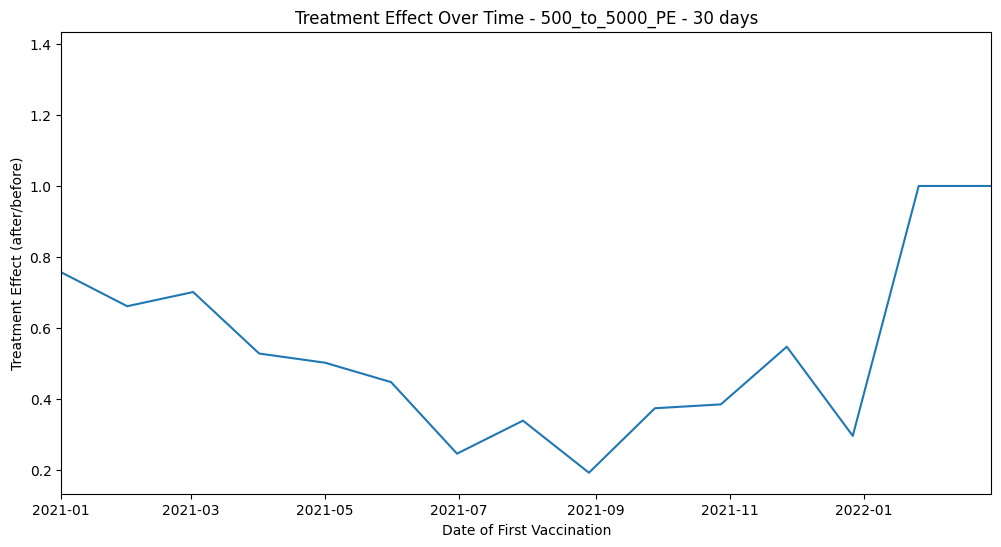

In [46]:
aggregation_days = 30

effects = compute_treatment_effect(
    five_hundred_to_five_thousand_pe_vax_people, aggregation_days
)
plot_treatment_effect(effects, "500_to_5000_PE", aggregation_days)

In [19]:
print(f"young_people count: {len(young_people)}")
print(f"max effect: {max(effects.values())}")

young_people count: 105878
max effect: 37.0


In [90]:
group = one_to_five_hundred_pe_vax_people
group_name = "1_to_500_PE"
baseline = 1 if group_name == "0_PE" else 0
aggregation_days = 1
(
    median_map,
    iqr_map,
    ci_map,
    effects,
    vax_ratio_median_map,
    novax_ratio_median_map,
) = run_matching_analysis(group, aggregation_days, group_name, 100)
vax_dates_distribution = get_vax_dates_distribution(group, aggregation_days)


iterating through people  10192
Processed 0 runs
iterating through people  10192
Processed 1 runs
iterating through people  10192
Processed 2 runs
iterating through people  10192
Processed 3 runs
iterating through people  10192
Processed 4 runs
iterating through people  10192
Processed 5 runs
iterating through people  10192
Processed 6 runs
iterating through people  10192
Processed 7 runs
iterating through people  10192
Processed 8 runs
iterating through people  10192
Processed 9 runs
iterating through people  10192
Processed 10 runs
iterating through people  10192
Processed 11 runs
iterating through people  10192
Processed 12 runs
iterating through people  10192
Processed 13 runs
iterating through people  10192
Processed 14 runs
iterating through people  10192
Processed 15 runs
iterating through people  10192
Processed 16 runs
iterating through people  10192
Processed 17 runs
iterating through people  10192
Processed 18 runs
iterating through people  10192
Processed 19 runs
iterating 

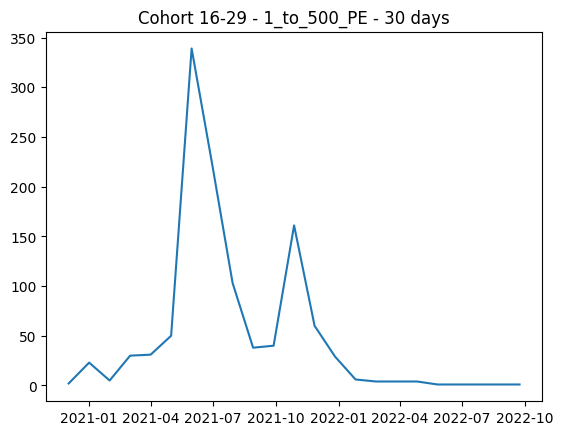

In [93]:
vax_dates_distribution = get_vax_dates_distribution(group, 30)
cohort = AgeCohort._16_29
date_map = vax_dates_distribution[cohort]
sorted_dates = sorted(date_map.keys())
vax_counts = [vax_dates_distribution[cohort].get(d, 0) for d in sorted_dates]
fig, ax = plt.subplots()
ax.plot(sorted_dates, vax_counts)
ax.set_title(f"Cohort {cohort} - {group_name} - 30 days")
plt.show()


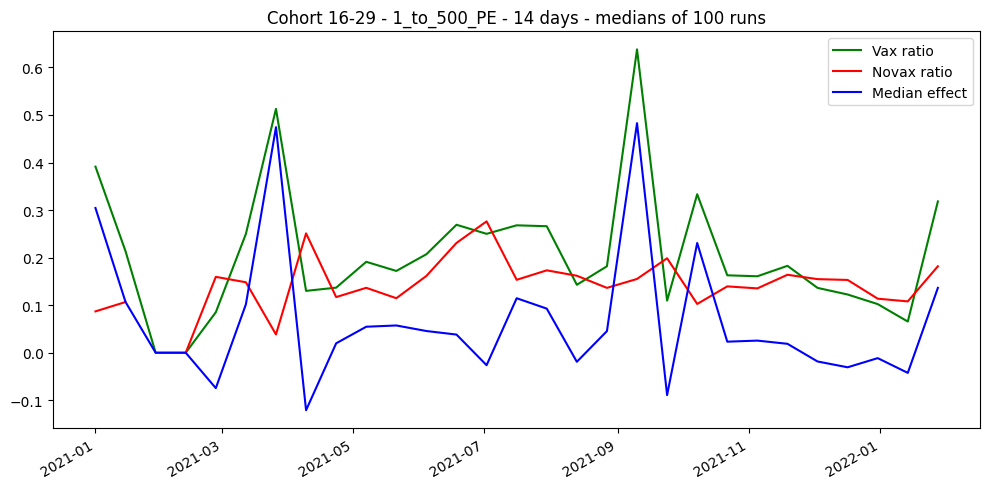

In [85]:
cohort = AgeCohort._16_29
date_map = median_map[cohort]
sorted_dates = sorted(date_map.keys())

y_mean = [median_map[cohort][d] for d in sorted_dates]
y_lower = [iqr_map[cohort][d][0] for d in sorted_dates]
y_upper = [iqr_map[cohort][d][1] for d in sorted_dates]
vax_ratio_y_mean = [vax_ratio_median_map[cohort][d] for d in sorted_dates]
novax_ratio_y_mean = [novax_ratio_median_map[cohort][d] for d in sorted_dates]

vax_counts = [vax_dates_distribution[cohort].get(d, 0) for d in sorted_dates]

fig, ax_left = plt.subplots(figsize=(10, 5))

# left axis
ax_left.plot(sorted_dates, vax_ratio_y_mean, label="Vax ratio", color="green")
ax_left.plot(sorted_dates, novax_ratio_y_mean, label="Novax ratio", color="red")
ax_left.plot(sorted_dates, y_mean, label="Median effect", color="blue")
# ax_left.fill_between(
#     sorted_dates, y_lower, y_upper, alpha=0.2, label="IQR", color="blue"
# )
# ax_left.axhline(baseline, color="black", linewidth=1)
# ax_left.set_ylabel("Effect value")


ax_left.set_title(
    f"Cohort {cohort} - {group_name} - {aggregation_days} days - medians of 100 runs"
)
fig.autofmt_xdate()
fig.tight_layout()

lines, labels = ax_left.get_legend_handles_labels()
ax_left.legend(lines, labels)

plt.show()
plt.close(fig)


In [71]:
folder_path = f"out/{POJISTOVNA}/matching_analysis/main_timeframe/{group_name}/{aggregation_days}_days_aggregation"
for cohort, date_map in median_map.items():
    sorted_dates = sorted(date_map.keys())

    y_mean = [median_map[cohort][d] for d in sorted_dates]
    y_lower = [iqr_map[cohort][d][0] for d in sorted_dates]
    y_upper = [iqr_map[cohort][d][1] for d in sorted_dates]

    vax_counts = [vax_dates_distribution[cohort].get(d, 0) for d in sorted_dates]

    fig, ax_left = plt.subplots(figsize=(10, 5))

    # left axis
    ax_left.plot(sorted_dates, y_mean, label="Median effect", color="blue")
    ax_left.fill_between(
        sorted_dates, y_lower, y_upper, alpha=0.2, label="IQR", color="blue"
    )
    ax_left.axhline(baseline, color="black", linewidth=1)
    ax_left.set_ylabel("Effect value")

    # right axis
    ax_right = ax_left.twinx()
    ax_right.plot(
        sorted_dates, vax_counts, linestyle="--", label="Vaccinated", color="orange"
    )
    ax_right.set_ylabel("Vaccinated count")

    ax_left.set_title(f"Cohort {cohort} - {group_name} - {aggregation_days} days")
    fig.autofmt_xdate()
    fig.tight_layout()

    # shared legend
    lines, labels = ax_left.get_legend_handles_labels()
    lines2, labels2 = ax_right.get_legend_handles_labels()
    ax_left.legend(lines + lines2, labels + labels2)

    os.makedirs(folder_path, exist_ok=True)
    fig.savefig(f"{folder_path}/{cohort}.png")
    plt.close(fig)


In [67]:
table = []


def get_median(median_map, cohort):
    values = median_map.get(cohort, {})
    return next(iter(values.values()), None)


def get_iqr(iqr_map, cohort):
    values = iqr_map.get(cohort, {})
    return next(iter(values.values()), None)  # (q1, q3)


def get_ci(ci_map, cohort):
    values = ci_map.get(cohort, {})
    return next(iter(values.values()), None)  # (ci_low, ci_high)


def get_total_vaccinations(vax_dates_distribution, cohort):
    date_map = vax_dates_distribution.get(cohort, {})
    return int(sum(date_map.values()))


for cohort in AgeCohort:
    median = get_median(median_map, cohort)
    iqr = get_iqr(iqr_map, cohort)
    ci = get_ci(ci_map, cohort)
    total_vax = get_total_vaccinations(vax_dates_distribution, cohort)

    table.append(
        {
            "věk": cohort.value,
            "Med": median,
            "IQR": iqr,
            "95% CI": ci,
            "počet očko": total_vax,
        }
    )

import polars as pl

df = pl.DataFrame(table)

df.write_json(f"{folder_path}/../effects_summary.json")
